In [1]:
import sys
print(sys.executable)

c:\entornos\tfg_env\Scripts\python.exe


c:\entornos\tfg_env\Scripts\python.exe
['hour', 'price', 'datetime']
Estadístico ADF: -6.4412
p-valor: 0.0000
La serie es estacionaria (p-valor <= 0.05).
Tamaño entrenamiento: 43824
Tamaño prueba: 24


c:\entornos\tfg_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\entornos\tfg_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\entornos\tfg_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                43824
Model:                 ARIMA(1, 0, 1)   Log Likelihood             -167827.246
Date:                Fri, 20 Mar 2026   AIC                         335662.492
Time:                        17:13:34   BIC                         335697.244
Sample:                             0   HQIC                        335673.445
                              - 43824                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         92.6386      3.481     26.615      0.000      85.817      99.461
ar.L1          0.9759      0.001   1201.274      0.000       0.974       0.977
ma.L1          0.3833      0.002    162.275      0.0

c:\entornos\tfg_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\entornos\tfg_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


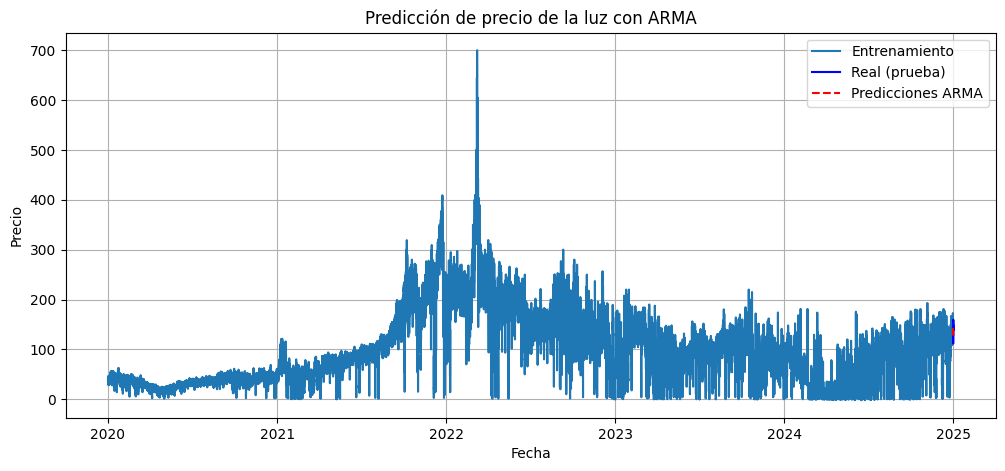

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error

# ------------------------------
# 1. Cargar los datos
# ------------------------------
df = pd.read_csv('precio_luz.csv', sep=";")

# Ver las primeras filas
print(df.columns.tolist())
# ------------------------------
# 2. Preparar la serie temporal
# ------------------------------
# Convertir la columna de datetime a tipo datetime y ponerla como indice
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Ordenar por fecha por si acaso
df.sort_index(inplace=True)

# Asigna frecuencia, para nosostros H para una frecuencia en horas
df = df.asfreq('H')   # o 'D' para dias

# Seleccionamos la columna de precio (la que queremos predecir)
#serie = df['price']   # precio contiene valores nulos, cambio de hora agosto
serie = df['price'].replace([np.inf, -np.inf], np.nan).dropna() #quitamos valores erroneos

# ------------------------------
# 3. Verificar estacionariedad (opcional pero recomendado)
# ------------------------------
# El modelo ARMA asume que la serie es estacionaria.
# Realizamos el test de Dickey-Fuller aumentado.
resultado = adfuller(serie)
print(f'Estadístico ADF: {resultado[0]:.4f}')
print(f'p-valor: {resultado[1]:.4f}')
if resultado[1] <= 0.05:
    print("La serie es estacionaria (p-valor <= 0.05)")
else:
    print("La serie NO es estacionaria. Se recomienda diferenciarla")
    # Diferenciamos una vez
    serie_diff = serie.diff().dropna()
    print("Se ha creado 'serie_diff' para continuar")
    # Vamos a trabajar con la serie diferenciada
    serie = serie_diff

# ------------------------------
# 4. Dividir en entrenamiento y prueba
# ------------------------------
# Por ejemplo, dejamos los últimos 24 puntos para prueba
train = serie[:-24]
test = serie[-24:]

print(f"Tamaño entrenamiento: {len(train)}")
print(f"Tamaño prueba: {len(test)}")

# ------------------------------
# 5. Elegir los órdenes p y q del modelo ARMA
# ------------------------------
# Para simplificar, probamos con p=1, q=1.
# Más adelante puedes probar otros valores (ej. (2,0,1), etc.)
p = 1
q = 1
# En ARIMA, el orden es (p, d, q). Como usamos ARMA, d=0.
modelo = ARIMA(train, order=(p, 0, q))

# Ajustar el modelo
modelo_ajustado = modelo.fit()

# Mostrar un resumen del modelo
print(modelo_ajustado.summary())

# ------------------------------
# 6. Predecir los valores del conjunto de prueba
# ------------------------------
# forecast recibe el número de pasos a predecir
predicciones = modelo_ajustado.forecast(steps=len(test))

# ------------------------------
# 7. Evaluar el modelo
# ------------------------------
# Calcular el error cuadrático medio (RMSE)
rmse = np.sqrt(mean_squared_error(test, predicciones))
print(f"RMSE en prueba: {rmse:.4f}")

# ------------------------------
# 8. Graficar resultados
# ------------------------------
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label='Entrenamiento')
plt.plot(test.index, test, label='Real (prueba)', color='blue')
plt.plot(test.index, predicciones, label='Predicciones ARMA', color='red', linestyle='--')
plt.title('Predicción de precio de la luz con ARMA')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)
plt.show()